In [2]:
import pandas as pd

df = pd.read_csv("fact_health_programs_cleaned.csv")
print(df.shape)          # (6912, 16)
print(df.dtypes)
df.head()

df.isna().sum()          # missing values per column
df.duplicated().sum()    # exact duplicate rows
df.describe()            # min/max/mean/quartiles for every numeric column

(6912, 16)
fact_id                            int64
date_id                            int64
state_id                           int64
program_id                         int64
program_coverage_pct             float64
people_screened                    int64
beneficiaries_reached              int64
maternal_health_beneficiaries      int64
child_immunization_count           int64
children_population                int64
adults_population                  int64
elderly_population                 int64
high_risk_individuals              int64
chronic_disease_patients           int64
health_vulnerability_index       float64
socioeconomic_score              float64
dtype: object


,fact_id,date_id,state_id,program_id,program_coverage_pct,people_screened,beneficiaries_reached,maternal_health_beneficiaries,child_immunization_count,children_population,adults_population,elderly_population,high_risk_individuals,chronic_disease_patients,health_vulnerability_index,socioeconomic_score
count,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6.912000e+03,6.912000e+03,6.912000e+03,6.912000e+03,6912.000000,6912.000000,6912.000000,6912.000000
mean,3456.500000,18.500000,16.500000,3.500000,67.198409,76197.157118,49437.261719,11181.949653,9.182594e+06,1.174597e+07,2.568202e+07,4.822170e+06,7453.952112,5251.346354,49.907943,55.026201
std,1995.466863,10.389046,9.233761,1.707949,18.353327,100208.479486,67152.234070,16278.611086,1.058963e+07,1.335196e+07,2.922183e+07,5.578667e+06,11302.865379,7869.240119,17.533538,19.738998
min,1.000000,1.000000,1.000000,1.000000,35.000000,165.000000,73.000000,12.000000,4.527100e+04,7.311400e+04,1.650390e+05,2.595900e+04,5.000000,5.000000,0.000000,0.000000
25%,1728.750000,9.750000,8.750000,2.000000,51.500000,5564.250000,3534.500000,726.000000,7.115968e+05,8.801198e+05,1.898146e+06,3.510388e+05,506.750000,340.000000,38.300000,41.800000
50%,3456.500000,18.500000,16.500000,3.500000,67.200000,44638.000000,28960.500000,5719.500000,6.631720e+06,8.567176e+06,1.848210e+07,3.445080e+06,3572.500000,2412.000000,50.000000,55.200000
75%,5184.250000,27.250000,24.250000,5.000000,82.900000,100294.000000,66021.500000,14953.000000,1.347138e+07,1.883050e+07,4.036823e+07,7.377750e+06,9420.750000,6750.500000,61.500000,68.600000
max,6912.000000,36.000000,32.000000,6.000000,99.000000,693723.000000,597393.000000,181093.000000,6.491928e+07,6.878338e+07,1.457884e+08,3.157662e+07,117649.000000,84337.000000,100.000000,100.000000


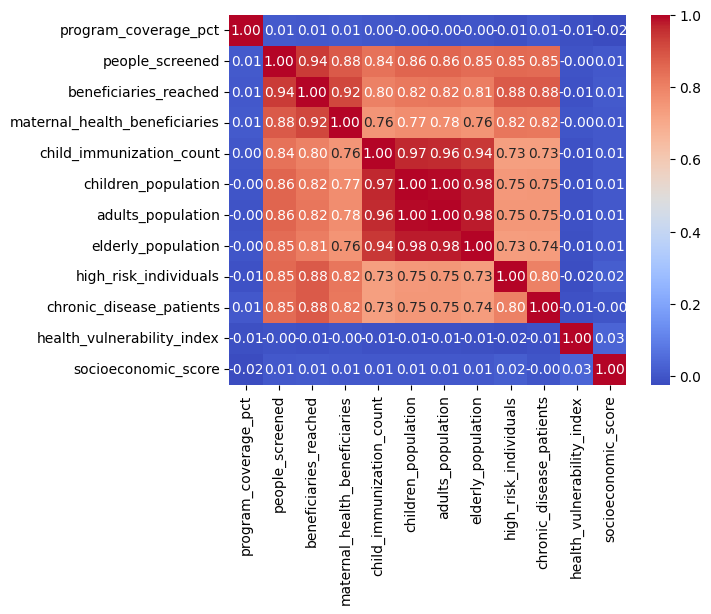

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.drop(columns=["fact_id","date_id","state_id","program_id"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

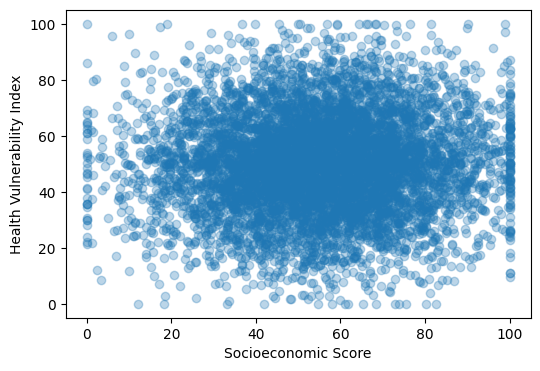

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(df["socioeconomic_score"], df["health_vulnerability_index"], alpha=0.3)
plt.xlabel("Socioeconomic Score")
plt.ylabel("Health Vulnerability Index")
plt.show()

In [6]:
numeric_columns = [
    "program_coverage_pct",
    "people_screened",
    "beneficiaries_reached",
    "maternal_health_beneficiaries",
    "child_immunization_count",
    "children_population",
    "adults_population",
    "elderly_population",
    "high_risk_individuals",
    "chronic_disease_patients",
    "health_vulnerability_index",
    "socioeconomic_score"
]

In [7]:
for col in numeric_columns:
    print("\n" + "="*50)
    print(f"Summary Statistics for: {col}")
    print(df[col].describe())


Summary Statistics for: program_coverage_pct
count    6912.000000
mean       67.198409
std        18.353327
min        35.000000
25%        51.500000
50%        67.200000
75%        82.900000
max        99.000000
Name: program_coverage_pct, dtype: float64

Summary Statistics for: people_screened
count      6912.000000
mean      76197.157118
std      100208.479486
min         165.000000
25%        5564.250000
50%       44638.000000
75%      100294.000000
max      693723.000000
Name: people_screened, dtype: float64

Summary Statistics for: beneficiaries_reached
count      6912.000000
mean      49437.261719
std       67152.234070
min          73.000000
25%        3534.500000
50%       28960.500000
75%       66021.500000
max      597393.000000
Name: beneficiaries_reached, dtype: float64

Summary Statistics for: maternal_health_beneficiaries
count      6912.000000
mean      11181.949653
std       16278.611086
min          12.000000
25%         726.000000
50%        5719.500000
75%       14

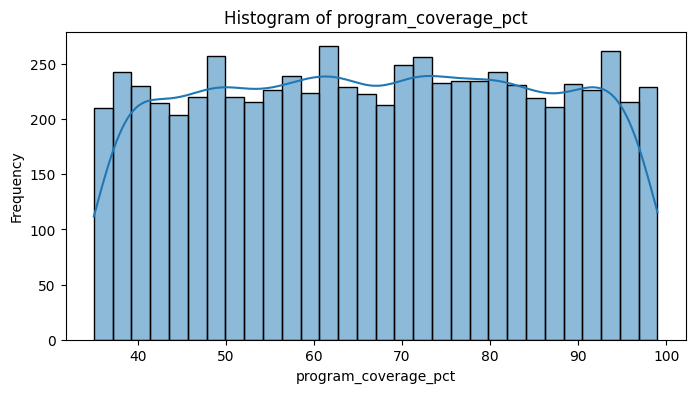

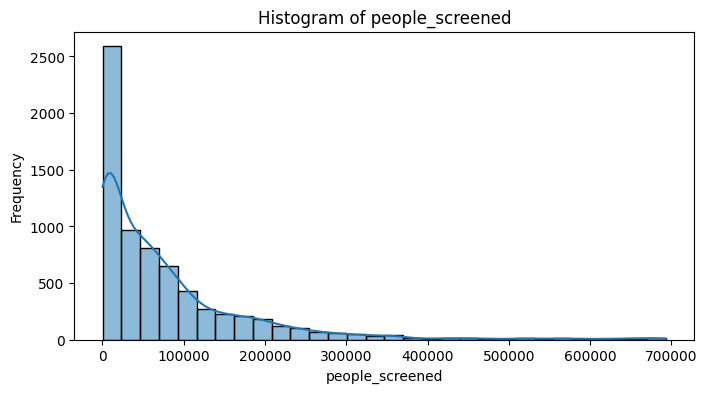

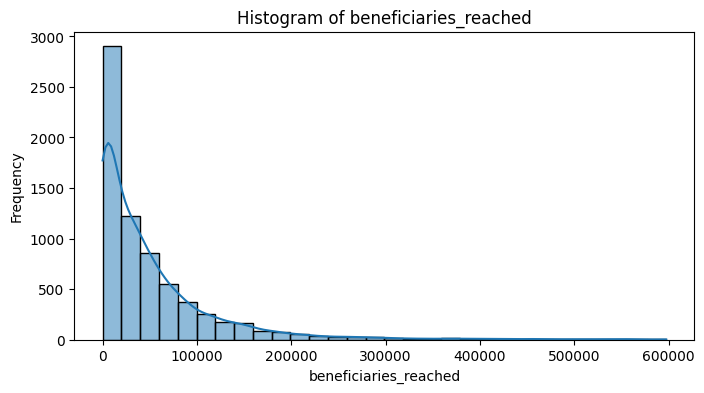

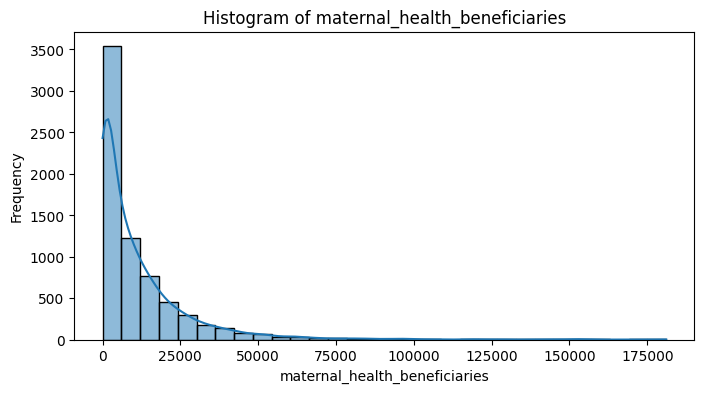

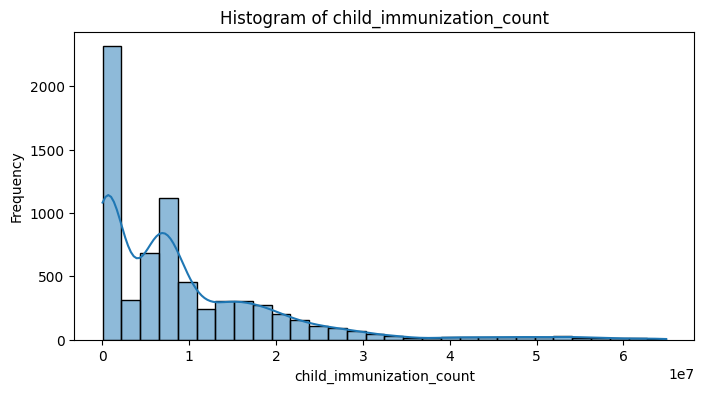

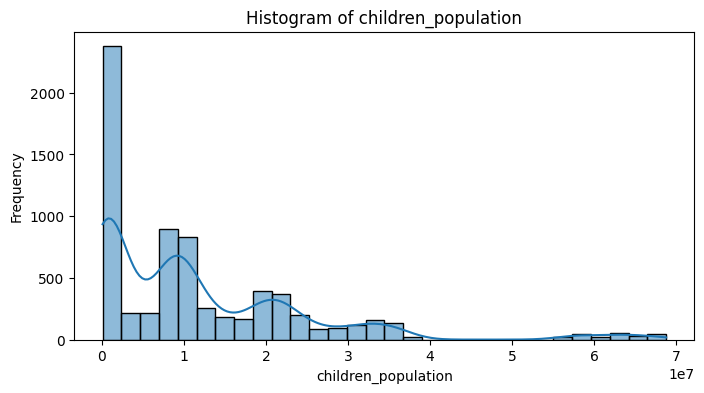

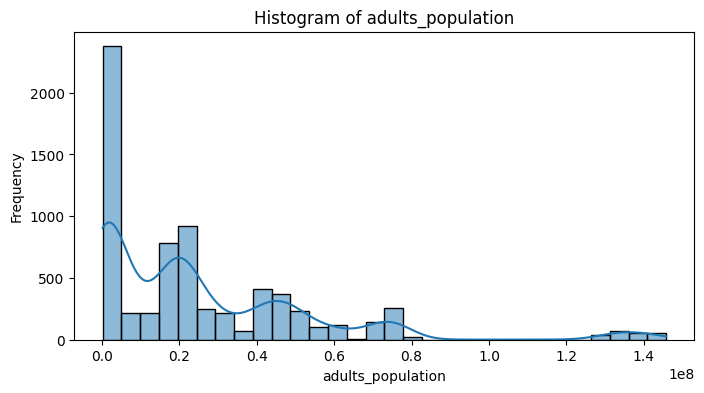

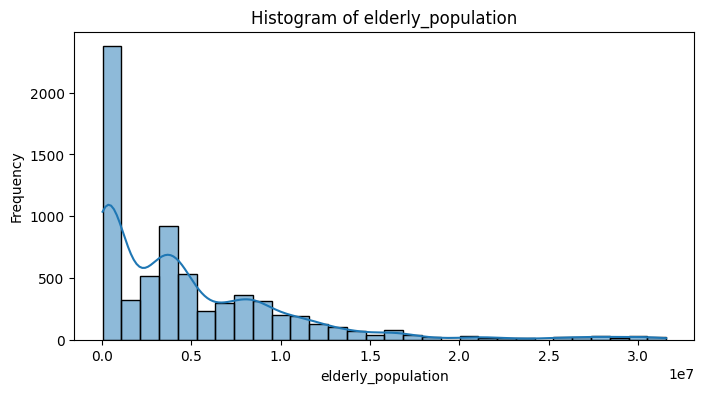

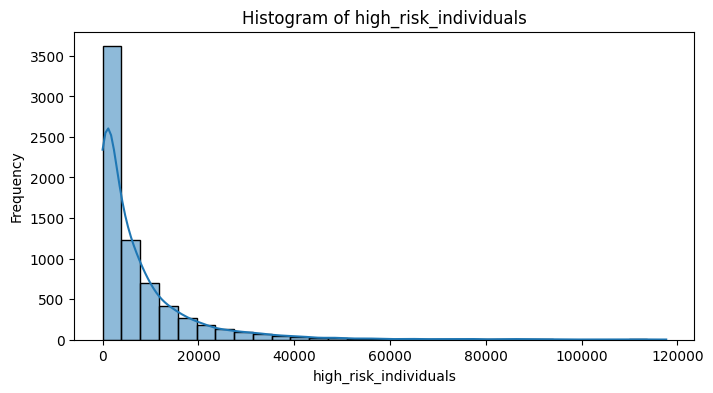

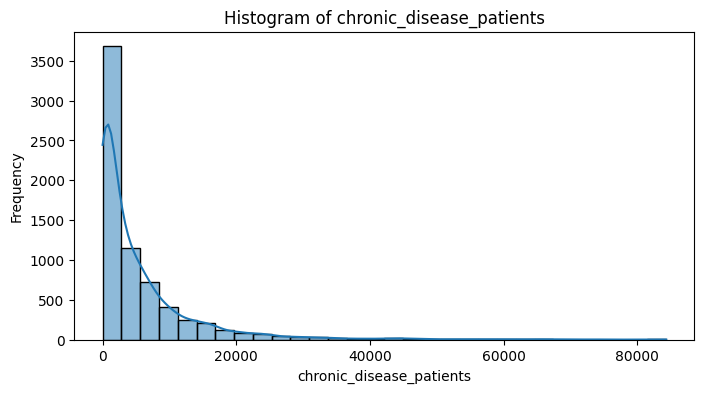

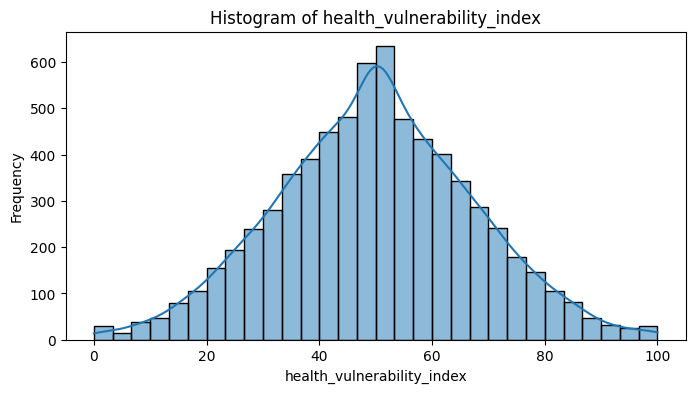

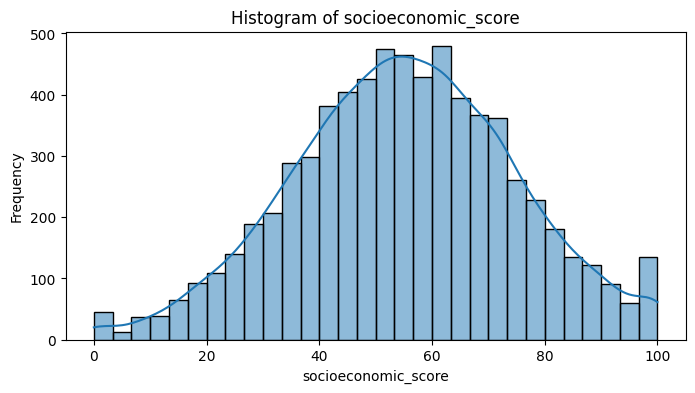

In [8]:
for col in numeric_columns:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f"Histogram of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

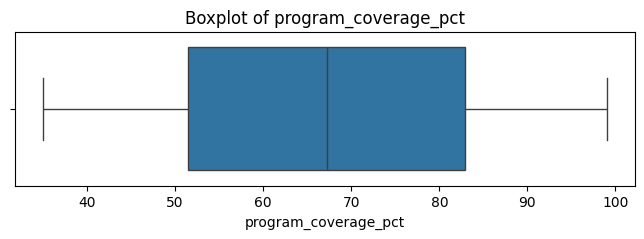

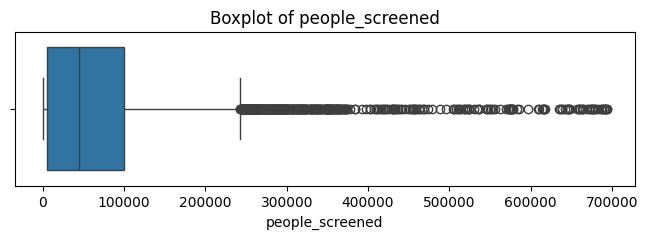

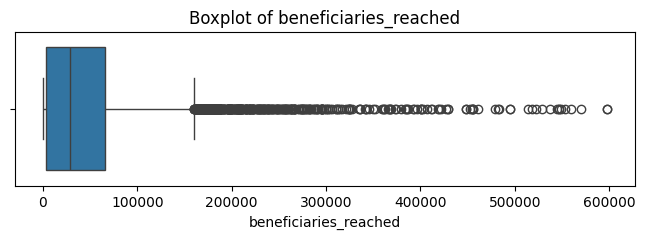

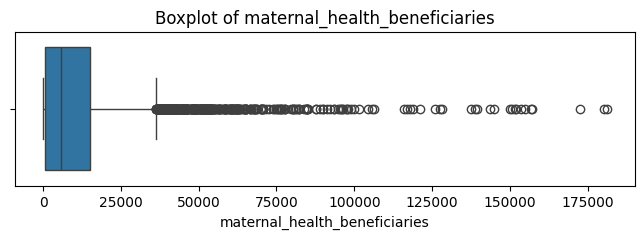

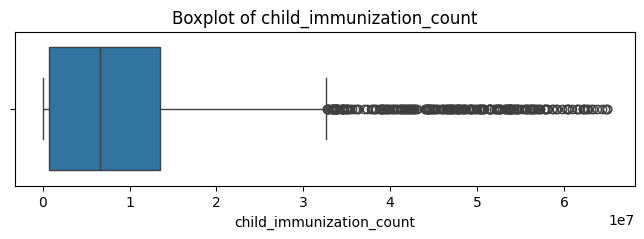

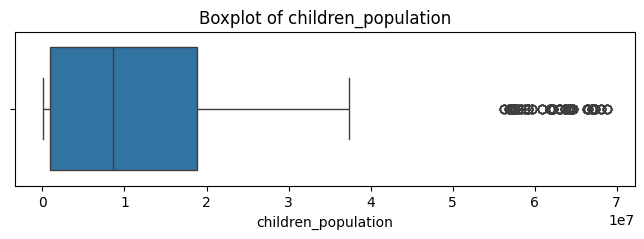

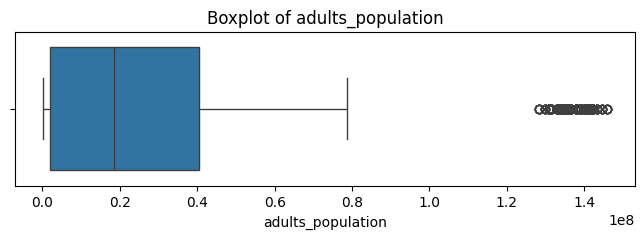

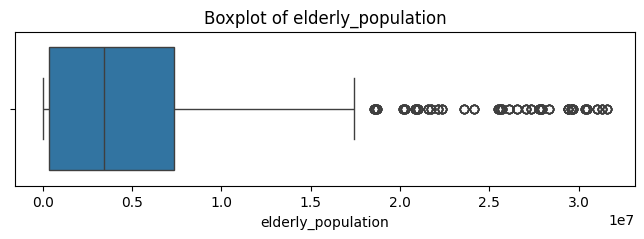

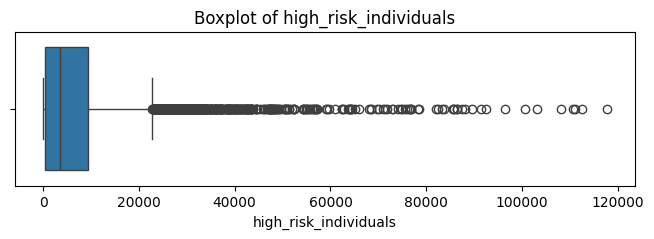

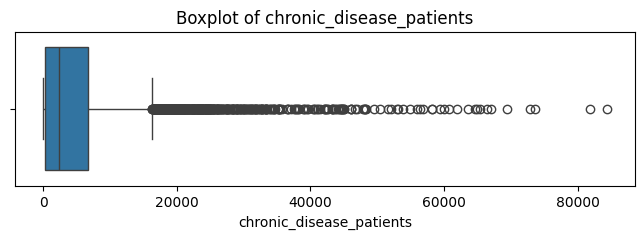

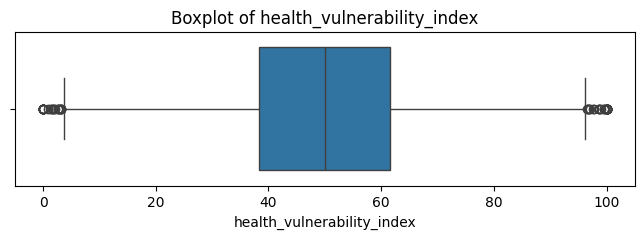

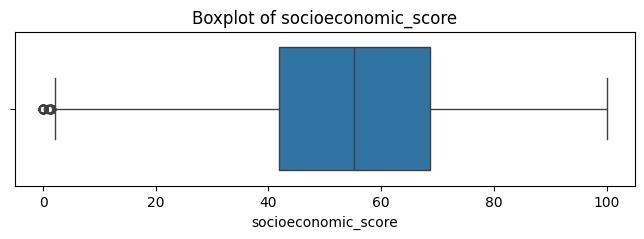

In [9]:
for col in numeric_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

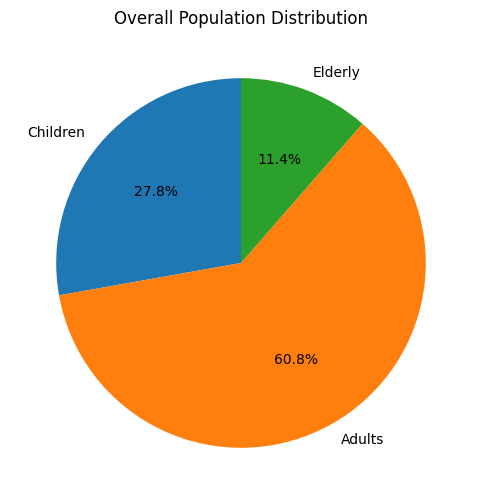

In [20]:
population = {
    "Children": df["children_population"].sum(),
    "Adults": df["adults_population"].sum(),
    "Elderly": df["elderly_population"].sum()
}

plt.figure(figsize=(6,6))

plt.pie(
    population.values(),
    labels=population.keys(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Population Distribution")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [12]:
state_population = df.groupby("state_id")[[
    "children_population",
    "adults_population",
    "elderly_population"
]].sum()

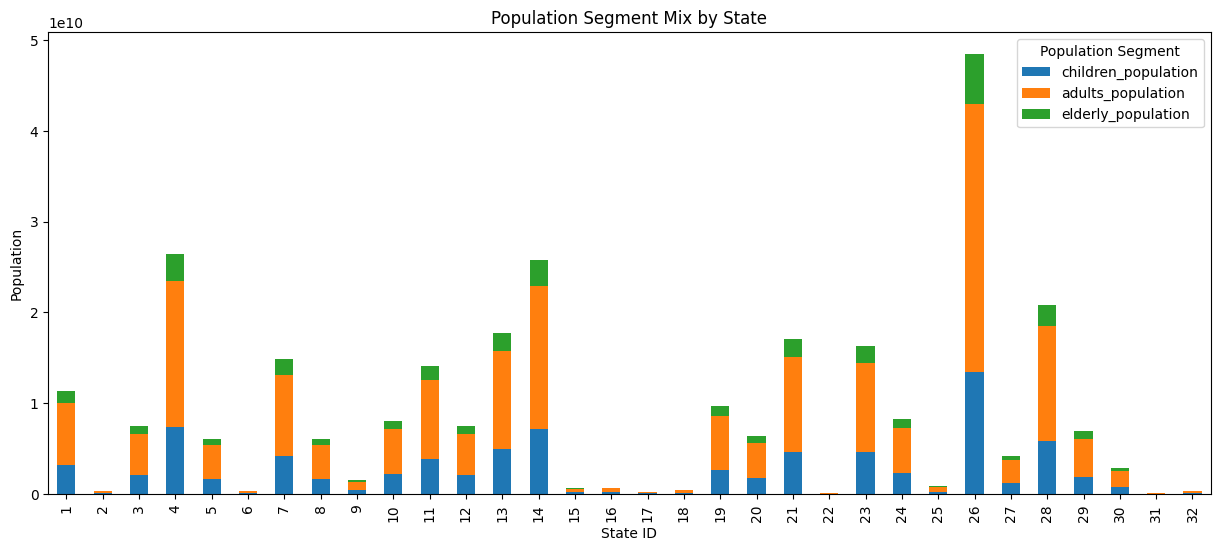

In [13]:
state_population.plot(
    kind="bar",
    stacked=True,
    figsize=(15,6)
)

plt.title("Population Segment Mix by State")

plt.xlabel("State ID")

plt.ylabel("Population")

plt.legend(title="Population Segment")

plt.show()

In [14]:
df["total_population"] = (
    df["children_population"]
    + df["adults_population"]
    + df["elderly_population"]
)

In [15]:
state_highrisk = df.groupby("state_id").agg({
    "high_risk_individuals":"sum",
    "total_population":"sum"
})

state_highrisk["High Risk %"] = (
    state_highrisk["high_risk_individuals"]
    /
    state_highrisk["total_population"]
)*100

state_highrisk.sort_values("High Risk %", ascending=False)

,high_risk_individuals,total_population,High Risk %
state_id,,,
15,128331,648568074,0.019787
22,28702,145642806,0.019707
24,1592816,8232770304,0.019347
6,62257,332788560,0.018708
32,58682,314525748,0.018657
19,1808082,9721346418,0.018599
18,83633,457487448,0.018281
31,11526,63156318,0.018250
16,129459,710426826,0.018223


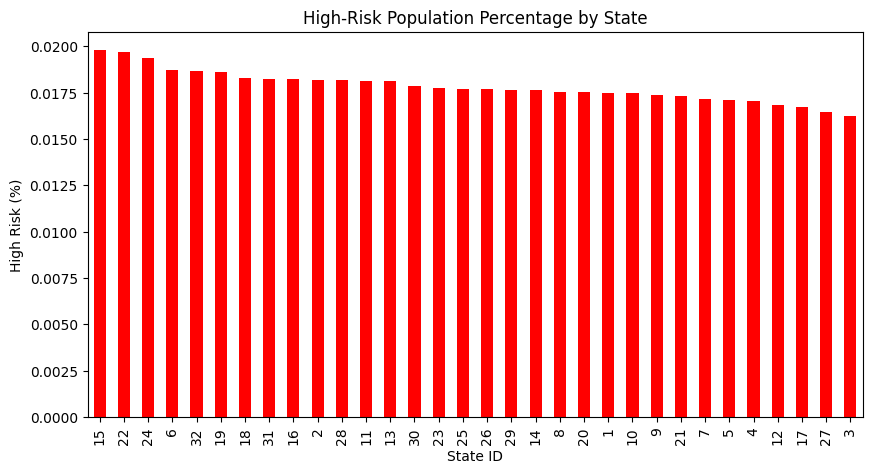

In [16]:
state_highrisk["High Risk %"].sort_values(
    ascending=False
).plot(
    kind="bar",
    color="red",
    figsize=(10,5)
)

plt.title("High-Risk Population Percentage by State")

plt.xlabel("State ID")

plt.ylabel("High Risk (%)")

plt.show()

In [17]:
state_chronic = df.groupby("state_id").agg({
    "chronic_disease_patients":"sum",
    "total_population":"sum"
})

state_chronic["Chronic Disease %"] = (
    state_chronic["chronic_disease_patients"]
    /
    state_chronic["total_population"]
)*100

state_chronic.sort_values("Chronic Disease %", ascending=False)

,chronic_disease_patients,total_population,Chronic Disease %
state_id,,,
24,1112172,8232770304,0.013509
19,1306900,9721346418,0.013444
15,87121,648568074,0.013433
8,807339,6062992176,0.013316
13,2331815,17772021396,0.013121
32,40320,314525748,0.012819
31,8092,63156318,0.012813
6,42568,332788560,0.012791
21,2166386,17025407778,0.012724


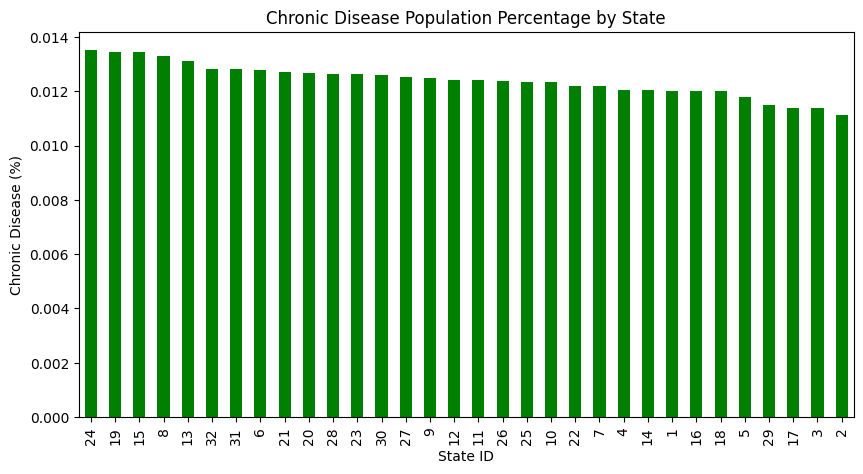

In [18]:
state_chronic["Chronic Disease %"].sort_values(
    ascending=False
).plot(
    kind="bar",
    color="green",
    figsize=(10,5)
)

plt.title("Chronic Disease Population Percentage by State")

plt.xlabel("State ID")

plt.ylabel("Chronic Disease (%)")

plt.show()

## Key Findings

• The dataset contains 6,912 records and 16 columns with no missing or duplicate values.

• Adults constitute the largest population segment, followed by children and elderly.

• Population composition varies across different states.

• States with higher health vulnerability generally have a larger number of high-risk individuals.

• The correlation analysis highlights relationships between population, vulnerability, and chronic disease indicators.

• State-wise analysis identifies regions with higher concentrations of high-risk individuals and chronic disease patients, which can help prioritize healthcare interventions.